In [ ]:
# loads the dataset from kaggle to google colab

from google.colab import drive
drive.mount('/content/drive')

!mkdir ~/.kaggle
!cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download grassknoted/asl-alphabet
!kaggle datasets download danrasband/asl-alphabet-test

!unzip asl-alphabet.zip
!unzip asl-alphabet-test.zip

!rm asl-alphabet.zip
!rm asl-alphabet-test.zip

!rm -r sample_data A B C D E F G H I J K L M N O P Q R S T U V W X Y Z del space nothing
!rm -r asl_alphabet_test

!mv asl_alphabet_train/asl_alphabet_train/* asl_alphabet_train
!rm -r asl_alphabet_train/asl_alphabet_train

!mv asl-alphabet-test asl_alphabet_test

Streaming output truncated to the last 5000 lines.
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing766.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing767.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing768.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing769.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing77.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing770.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing771.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing772.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing773.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing774.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing775.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing776.jpg  
  inflating: asl_alphabet_train/asl_al

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)), # resize to 64x64
    transforms.RandomRotation(15), # randomly rotate images upto 15 degrees
    transforms.RandomHorizontalFlip(), # randomly flip the images horizontally
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # randomly shifts images and random scaling
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05), # apply brightest, contrast, saturation, and hue variations
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)), # apply gaussian blur to the images
    transforms.ToTensor(), # converts to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # normalize dataset with mean and std from imagenet
])

# no data augmentation for test transform
test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 1024 # high bactch size to maximize gpu ram

# load train dataset
train_dataset_path = 'asl_alphabet_train'
train_dataset = ImageFolder(train_dataset_path, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# load test dataset
val_dataset_path = 'asl_alphabet_test'
val_dataset = ImageFolder(val_dataset_path, transform=test_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

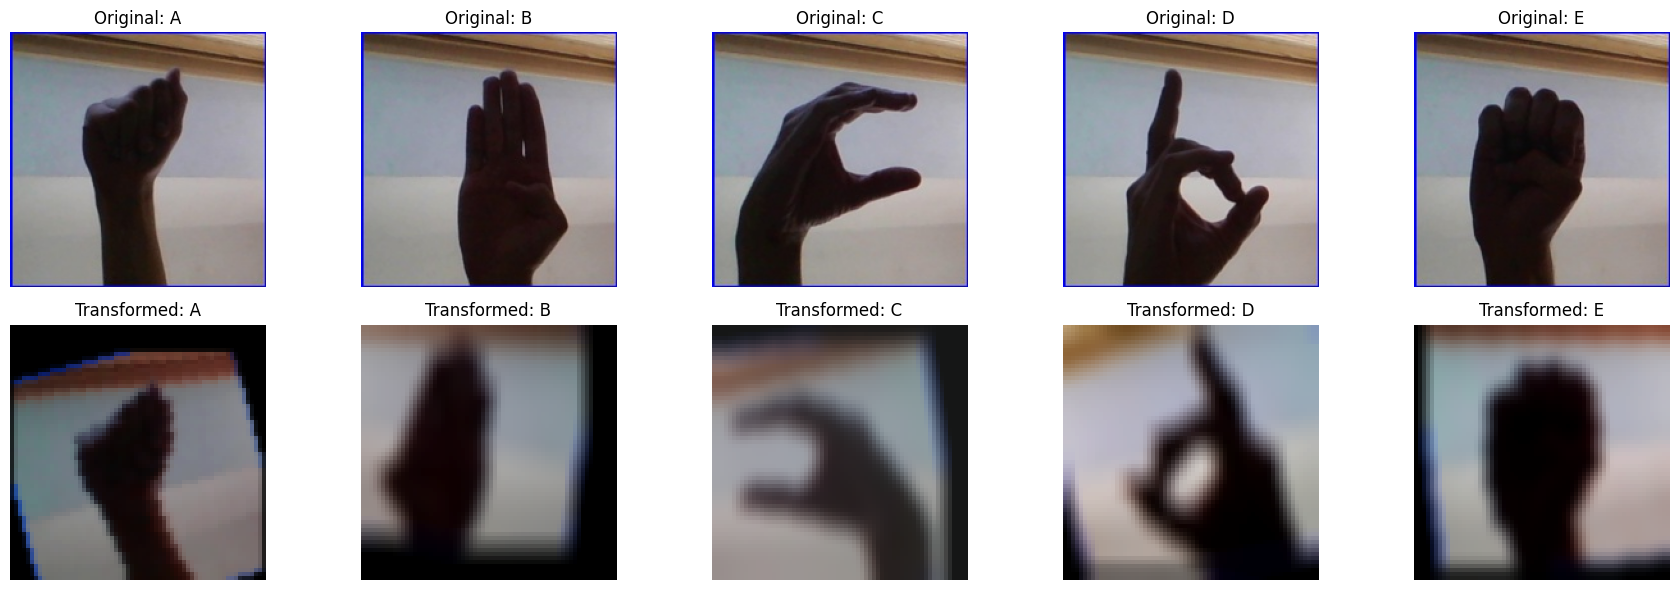

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# mean and std from imaget stats
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
class_names = train_dataset.classes

# get the indices of the first images of letters A - E
indices = [i*3000 for i in range(5)]

# 2x5 subplot to display 10 images
fig, axes = plt.subplots(2, 5, figsize=(18, 6))

# iterate through the indices
for col, idx in enumerate(indices):
    # plot original dataset
    # get the img_path and label of the image
    img_path, label = train_dataset.samples[idx]
    img = Image.open(img_path)
    axes[0, col].imshow(img) # display the image
    axes[0, col].set_title(f"Original: {class_names[label]}")
    axes[0, col].axis('off')

    # plot transformed dataset
    # get the tensor (transformation already applied)
    img_tensor, label = train_dataset[idx]
    # unormalize the image
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1) # ensures the pixel values are [0-1]
    axes[1, col].imshow(img_np)
    axes[1, col].set_title(f"Transformed: {class_names[label]}")
    axes[1, col].axis('off')

plt.tight_layout()
plt.show() # show the plot

In [ ]:
import torch
import torch.nn as nn

# Simple custom CNN for image classification
class AslNet(nn.Module):
    def __init__(self, num_classes):
        super(AslNet, self).__init__()
        # first conv block
        # conv layer with 32 3x3 filter
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU() # ReLU activation function
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pool, stride of 2

        # 2nd conv block
        # conv layer with 64 3x3 filter
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU() # ReLU activation function
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pool, stride of 2

        # 3rd conv block
        # conv layer with 128 3x3 filter
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU() # ReLU activation function
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pool, stride of 2

        # fully connected layers
        self.flatten = nn.Flatten() # flatten output for dense layer
        self.fc1 = nn.Linear(in_features=128 * 8 * 8, out_features=512) # dense layer with 512 neurons
        self.relu_fc = nn.ReLU() # ReLU activation for dense layer
        self.dropout = nn.Dropout(p=0.5) # dropout for regularization
        self.fc2 = nn.Linear(in_features=512, out_features=num_classes) # output layer

    def forward(self, x):
        x = self.conv1(x)    # first conv
        x = self.relu1(x)    # activation
        x = self.maxpool1(x) # pooling

        x = self.conv2(x)    # second conv
        x = self.relu2(x)    # activation
        x = self.maxpool2(x) # pooling

        x = self.conv3(x)    # third conv
        x = self.relu3(x)    # activation
        x = self.maxpool3(x) # pooling

        x = self.flatten(x)  # flatten for dense layer
        x = self.fc1(x)      # first dense layer
        x = self.relu_fc(x)  # activation
        x = self.dropout(x)  # dropout
        x = self.fc2(x)      # output layer

        return x

In [ ]:
import torch.optim as optim

num_classes = len(train_dataset.classes) # number of classes
model = AslNet(num_classes) # make an instance of AslNet

# use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # move model to the device

# Use categorical cross-entropy loss function
# used for multiclass classfication
criterion = nn.CrossEntropyLoss()

lr = 0.001 # learning rate for the optimizer
# use adam optimizer for training
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
from tqdm import tqdm # for progres bar

num_epochs = 20 # number of epochs

# to keep tracks of the losses and accuracy
# used for plotting later
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# to keep track of the best validation accuracy
best_accuracy = -1

# print dataset and device info
print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"Class names: {train_dataset.classes}")
print(f"Starting training on {device}")
print('-' * 50)

for epoch in range(num_epochs):
  model.train() # set to training mode

  # to track training loss
  train_loss = 0.0
  # used for calculating train accuracy
  train_correct = 0
  train_total = 0

  # training loop with progress bar
  train_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Train]')
  for inputs, labels in train_bar:
    # move to device
    inputs = inputs.to(device)
    labels = labels.to(device)


    optimizer.zero_grad() # reset the gradients
    outputs = model(inputs) # forward pass
    loss = criterion(outputs, labels) # get loss
    loss.backward() # backpropagation
    optimizer.step() # update the weights

    train_loss += loss.item() * inputs.size(0) # add the loss
    _, predicted = outputs.max(1) # get predictions
    train_correct += predicted.eq(labels).sum().item() # add correct predictions
    train_total += labels.size(0) # add to total

    # print the current training loss and accuracy
    train_bar.set_postfix({
        'Loss': f'{loss.item():.4f}',
        'Acc': f'{100.*train_correct/train_total:.2f}%'
    })


  train_loss /= len(train_loader.dataset) # calc avg loss
  train_acc = 100.*train_correct/train_total # calc accuracy
  train_losses.append(train_loss) # add loss for the current epoch
  train_accuracies.append(train_acc) # add accuracy for the current epoch

  model.eval() # set to evaluation mode
  # to track validation loss
  val_loss = 0.0
  # used for calculating validation accuracy
  val_correct = 0
  val_total = 0

  # validation loop with progress bar
  val_bar = tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Val]')
  with torch.no_grad():
    for inputs, labels in val_bar:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs) # forward pass
      loss = criterion(outputs, labels) # get the loss

      val_loss += loss.item() * inputs.size(0) # add the loss
      _, predicted = outputs.max(1) # get the predictions
      val_correct += predicted.eq(labels).sum().item() # add correct predictions
      val_total += labels.size(0) # add to total

      # print the current validation loss and accuracy
      val_bar.set_postfix({
          'Loss': f'{loss.item():.4f}',
          'Acc': f'{100.*val_correct/val_total:.2f}%'
      })

    val_loss /= len(val_loader.dataset) # calc avg validation loss
    val_acc = 100.*val_correct/val_total # calc accuracy

    # save model if it's has the best validation acc
    if val_acc > best_accuracy:
      best_accuracy = val_acc
      torch.save(model.state_dict(), 'AslNet.pth') # save as 'AslNet.pth'

    val_losses.append(val_loss) # add loss for the current epoch
    val_accuracies.append(val_acc) # add acc for the current epoch

    # print the final loss and accuracy of both training and validation
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    print('-' * 50)

Train dataset: 87000
Val dataset: 870
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Starting training on cuda
--------------------------------------------------


Epoch 1/20 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it, Loss=5.4481, Acc=3.91%]


Epoch 1/20
Train Loss: 2.7683 | Train Acc: 18.78%
Val Loss: 5.4481 | Val Acc: 3.91%
--------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.05s/it, Loss=5.5946, Acc=7.24%]


Epoch 2/20
Train Loss: 1.8182 | Train Acc: 41.79%
Val Loss: 5.5946 | Val Acc: 7.24%
--------------------------------------------------


...

Epoch 18/20
Train Loss: 0.3278 | Train Acc: 88.77%
Val Loss: 10.2902 | Val Acc: 14.02%
--------------------------------------------------


Epoch 19/20 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it, Loss=10.7288, Acc=14.48%]


Epoch 19/20
Train Loss: 0.3181 | Train Acc: 89.16%
Val Loss: 10.7288 | Val Acc: 14.48%
--------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it, Loss=9.8675, Acc=16.21%]

Epoch 20/20
Train Loss: 0.3037 | Train Acc: 89.54%
Val Loss: 9.8675 | Val Acc: 16.21%
--------------------------------------------------


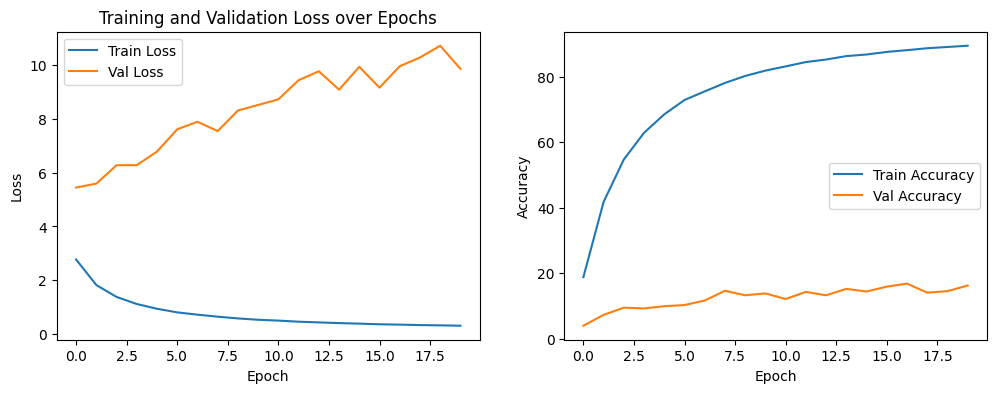

In [ ]:
plt.figure(figsize=(12, 4))

# plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()

# plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()

plt.show() # show the plot

Test Accuracy: 16.78%


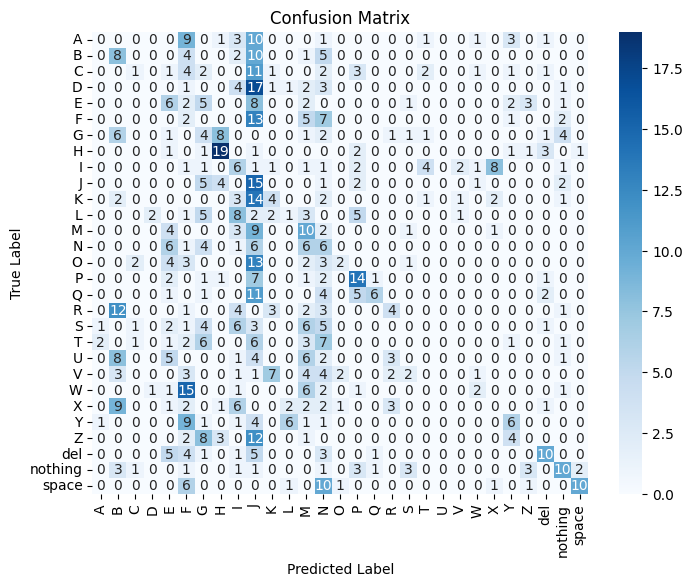

In [ ]:
import seaborn as sns # for heatmap
from sklearn.metrics import confusion_matrix # for computing the confusion matrix

model = AslNet(num_classes) # initialize AslNet
model_path = 'AslNet.pth'
model.load_state_dict(torch.load(model_path)) # load the trained weights to AslNet
model = model.to(device) # move to device

# for calculatin acc
correct = 0
total = 0

# to keep track of the true label and predicted label
all_labels = []
all_preds = []

model.eval() # set to evaluation mode

with torch.no_grad():
  for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs) # forward pass
    _, predicted = outputs.max(1) # get the predictions

    correct += (predicted == labels).sum().item() # add correct predictions
    total += labels.size(0) # add to total

    # add true labels and prediction
    # move to cpu to create numpy array
    all_labels.extend(labels.cpu().numpy())
    all_preds.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total # calc accuracy
print(f'Test Accuracy: {accuracy:.2f}%') # print accuracy

class_names = val_dataset.classes # get class names
cm = confusion_matrix(all_labels, all_preds) # calculate the confusion matix
# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()